In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from ISLP.models import ModelSpec as MS, summarize

The first cell is to import the needed libraries for the model.

What each library actually does?

1 - numpy is here because it's needed to run the equeations that we will use in our model.

2 - pandas is the library that will allow us to create tables in python, we call this table a dataframe, we could use numpys arrays but dataframes is more efficient.

3 - from matplotlib we only needs the pyplot model, we will use it to illustrate the scatter and residual plots.

4 - statsmodel is the library that will provide us with the statistics and mietrics we need to evaluate our model, we will use the api submodel from it only, .api is the submodule that holds its main tools. The one we'll use is sm.OLS, where OLS stands for ordinary least squares, the method that finds the best-fitting line.

5 - ModelSpec is used to build the model in the suitable form that will be used to fit it, it's all about the configurations thats needed.

6 - After fitting the model, statsmodels can print a huge wall of text with dozens of numbers. summarize(results) boils it down to a small table with just the key columns (coefficient, standard error, t-statistic, p-value).

In [2]:
df = pd.read_csv("../../Data/raw/master_raw_laps.csv")

print(df.shape)
print(df.columns.tolist())
df.head()

(57813, 37)
['Time', 'Driver', 'DriverNumber', 'LapTime', 'LapNumber', 'Stint', 'PitOutTime', 'PitInTime', 'Sector1Time', 'Sector2Time', 'Sector3Time', 'Sector1SessionTime', 'Sector2SessionTime', 'Sector3SessionTime', 'SpeedI1', 'SpeedI2', 'SpeedFL', 'SpeedST', 'IsPersonalBest', 'Compound', 'TyreLife', 'FreshTyre', 'Team', 'LapStartTime', 'LapStartDate', 'TrackStatus', 'Position', 'Deleted', 'DeletedReason', 'FastF1Generated', 'IsAccurate', 'LapTimeSeconds', 'Season', 'RoundNumber', 'EventName', 'BaseLapTime', 'LapTimeDelta']


,Time,Driver,DriverNumber,LapTime,LapNumber,Stint,PitOutTime,PitInTime,Sector1Time,Sector2Time,...,Deleted,DeletedReason,FastF1Generated,IsAccurate,LapTimeSeconds,Season,RoundNumber,EventName,BaseLapTime,LapTimeDelta
0,0 days 01:04:15.340000,VER,1,0 days 00:01:40.236000,1.0,1.0,NaN,NaN,NaN,0 days 00:00:42.325000,...,False,NaN,False,False,100.236,2022,1,Bahrain Grand Prix,97.528,2.708
1,0 days 01:05:53.220000,VER,1,0 days 00:01:37.880000,2.0,1.0,NaN,NaN,0 days 00:00:31.285000,0 days 00:00:42.269000,...,False,NaN,False,True,97.880,2022,1,Bahrain Grand Prix,97.528,0.352
2,0 days 01:07:31.577000,VER,1,0 days 00:01:38.357000,3.0,1.0,NaN,NaN,0 days 00:00:31.499000,0 days 00:00:42.474000,...,False,NaN,False,True,98.357,2022,1,Bahrain Grand Prix,97.528,0.829
3,0 days 01:09:10.143000,VER,1,0 days 00:01:38.566000,4.0,1.0,NaN,NaN,0 days 00:00:31.342000,0 days 00:00:42.674000,...,False,NaN,False,True,98.566,2022,1,Bahrain Grand Prix,97.528,1.038
4,0 days 01:10:49.020000,VER,1,0 days 00:01:38.877000,5.0,1.0,NaN,NaN,0 days 00:00:31.498000,0 days 00:00:42.854000,...,False,NaN,False,True,98.877,2022,1,Bahrain Grand Prix,97.528,1.349


Once again, we will go through every line here in order to have a better grasp about actual way to implement the code.

1 - pd.read_csv(...) calls the pandas tool (remember pd from Cell 1) that reads a CSV file and turns it into a table, as we can see in the output.

2 - We have 2 print statements, the first one is responsible for printing the size of the table that is used to store the data which is 57k rows with 37 columns.

3 - df.columns is the list of column names (LapTime, TyreLife, and so on)---> .tolist() converts it into a plain Python list, which prints more cleanly on one line.

4 - df.head() is used to get the first 5 rows of the table.

In [3]:
print(df["LapTimeSeconds"].dtype)
print(df["LapTimeSeconds"].isna().sum())
print(df["LapTimeSeconds"].describe())

float64
0
count    57813.000000
mean        89.013454
std         10.776629
min         67.012000
25%         80.807000
50%         87.128000
75%         97.624000
max        116.983000
Name: LapTimeSeconds, dtype: float64


This time, we are checking the data type for the LapTimeSeconds Coulmn, since we need it as a float no be able to perform further operations.

.isna() goes through every row and answers True if the value is missing, False if not.
.sum() adds those up. Python treats True as 1 and False as 0, so the sum is the count of missing values, which is 0 here.

The last print statement is to show some statistical data about that same column, the most important thing would be the std [Standard deviation], and it shows that there is a spread of 10 seconds, either Negative or Positvie, around the avarage lap time, which is 89 seconds.

This may look like a big number, however, it's because the 57K laps are gathered from different tracks, so it's understandable that some tracks would be shorter or larger.


In [4]:
n_before = len(df)

df = df[df["PitInTime"].isna()]
df = df[df["PitOutTime"].isna()]
df = df[df["TrackStatus"].astype(str) == "1"]
df = df[df["Deleted"].fillna(False) == False]
df = df[df["TyreLife"].notna()]

print(n_before, "->", len(df), "laps kept")

57813 -> 55089 laps kept


Here we are just cleaning the data, removing the laps that would be considered as a noise to the model.

Every line here is basically a kind of a filter that checks a condition.

In [5]:
counts = (df.groupby(["Season", "EventName", "Compound"])
            .size()
            .sort_values(ascending=False))
print(counts.head(15))

Season  EventName                  Compound    
2023    Miami Grand Prix           HARD            779
        Abu Dhabi Grand Prix       HARD            776
2024    Dutch Grand Prix           HARD            771
2022    Canadian Grand Prix        HARD            734
2024    Hungarian Grand Prix       HARD            724
        Bahrain Grand Prix         HARD            711
2023    Canadian Grand Prix        HARD            709
2024    Australian Grand Prix      HARD            689
        São Paulo Grand Prix       INTERMEDIATE    684
        Emilia Romagna Grand Prix  HARD            662
2023    Azerbaijan Grand Prix      HARD            661
2024    Azerbaijan Grand Prix      HARD            661
        Italian Grand Prix         HARD            661
2023    Hungarian Grand Prix       HARD            654
        Australian Grand Prix      HARD            634
dtype: int64


1 - groupby sorts the laps into buckets. Here, every unique combination of season, race name and tyre compound gets its own bucket.

I think the rest doesn't need an explaination.

Now we just choose one of these groups as aour target for the module we are building.

In [8]:
subset = df[(df["Season"] == 2024) &
            (df["EventName"] == "Bahrain Grand Prix") &
            (df["Compound"] == "HARD")].copy()

print(len(subset))

711


This is the same df[condition] pattern from Cell 4, with three conditions combined, as explained before, we need to pick a group with similar traits, so that we have a single metric we are moving forward with.

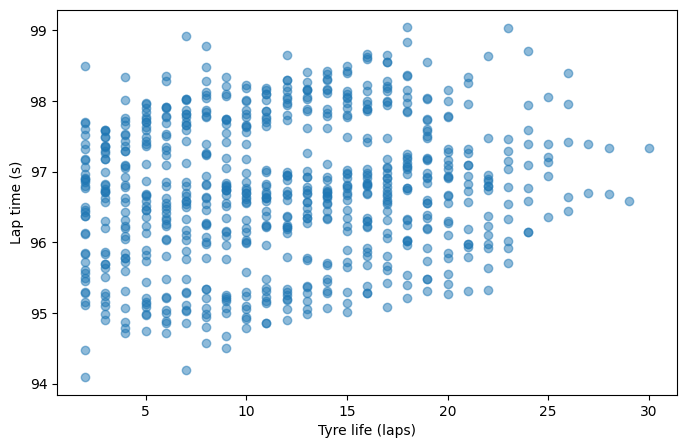

In [9]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(subset["TyreLife"], subset["LapTimeSeconds"], alpha=0.5)
ax.set_xlabel("Tyre life (laps)")
ax.set_ylabel("Lap time (s)")
plt.show()

Right now, we only have one variable to use, tyre life, which is a problem, since as we can see now, it's not able to actually provide a very helpfull feedback to us, there are a lot of other variables that will influence the Laptime variable as well, and this plot only shows us how much it's influnced by tyre life alone.

In [11]:
x = subset["TyreLife"]
y = subset["LapTimeSeconds"]

b1 = ((x - x.mean()) * (y - y.mean())).sum() / ((x - x.mean())**2).sum()
b0 = y.mean() - b1 * x.mean()

print(b1, b0)

0.024520516428324264 96.44107930757072


In [10]:
X = MS(["TyreLife"]).fit_transform(subset)
y = subset["LapTimeSeconds"]

model = sm.OLS(y, X)
results = model.fit()

summarize(results)

,coef,std err,t,P>|t|
intercept,96.4411,0.078,1228.794,0.0
TyreLife,0.0245,0.006,4.186,0.0


This can be used as the estimation coefficinets for our model: lap time = 96.4411 + 0.0245 × TyreLife

X = MS(["TyreLife"]).fit_transform(subset), This builds the X table for the regression. Reading it left to right:

- MS(["TyreLife"]) creates a model specification, a recipe that says "my predictor is the column TyreLife

- .fit_transform(subset) applies the recipe to your data. It does two things in one step: fit studies the data to learn what the recipe needs, and transform produces the finished table.

The result is stored in X, a table with two columns: intercept (all 1s, the column we discussed after Cell 1) and TyreLife (your tyre ages)

model = sm.OLS(y, X): sm.OLS is the statsmodels tool for ordinary least squares, the method that finds the best-fitting straight line.


results = model.fit():
This is where the calculation happens. .fit() finds the intercept and slope that make the line sit as close as possible to all 711 dots. "Close" means the sum of the squared vertical distances from each dot to the line is as small as possible, which is where the name "least squares" comes from. Everything about the fit is stored in results.




In [12]:
print("R-squared:", results.rsquared)
print("RSE:", np.sqrt(results.scale))
print(results.conf_int(alpha=0.05))

R-squared: 0.024123332157829913
RSE: 0.9919547009269781
                   0          1
intercept  96.286990  96.595169
TyreLife    0.013021   0.036020


What R² means: the share of the variation in lap time that the model explains, from 0 (nothing) to 1 (everything). It's the book's formula 1 − RSS/TSS.

TSS is how much the laps vary around their overall average.

RSS is how much they still vary around your line.

If the line removes little of that variation, RSS is close to TSS and R² is near 0.


What RSE means: the typical amount by which your predictions miss, in the units of Y. If RSE is about 1.0, then predicting a lap time from tyre age alone will typically be off by about a second. Compare that with the effect size:

The line rises only 0.0245 s per lap, so across a 20-lap stint the line moves by about 0.5 s, which is smaller than the typical miss.

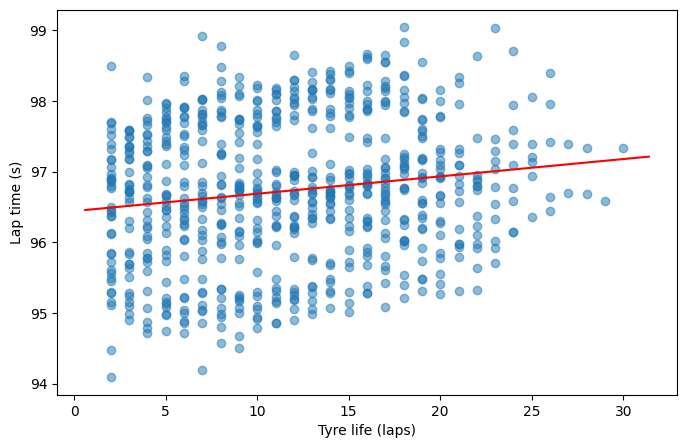

In [13]:
def abline(ax, b, m, **kwargs):
    xlim = ax.get_xlim()
    ax.plot(xlim, [m * xlim[0] + b, m * xlim[1] + b], **kwargs)

fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(subset["TyreLife"], y, alpha=0.5)
abline(ax, results.params.iloc[0], results.params.iloc[1], color="red")
ax.set_xlabel("Tyre life (laps)")
ax.set_ylabel("Lap time (s)")
plt.show()

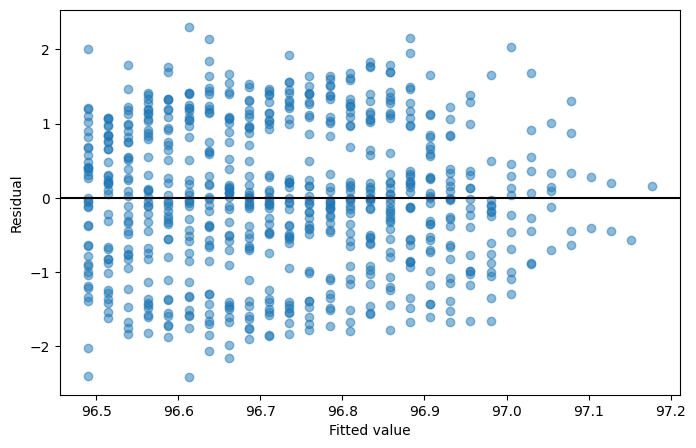

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(results.fittedvalues, results.resid, alpha=0.5)
ax.axhline(0, color="black")
ax.set_xlabel("Fitted value")
ax.set_ylabel("Residual")
plt.show()